In [1]:
from astropy.table import Table 

# load data onto an astropy table

ceers_path = '/home/caltech-msanche3/data/ceers_cat_v1.0_final.fits'
ceers_data = Table.read(ceers_path)
# change units of flux from nJy to microJy so eazy fits correctly
for col in ceers_data.colnames:
    if '_FLUX' in col or '_FLUXERR_SE' in col:
        ceers_data[col] = ceers_data[col] * 0.001


In [2]:
#for i in range(len(ceers_data)):
    #print(ceers_data[i]['NUMBER','RA','DEC','LP_Z_BEST'])
# list of id numbers
# 52480 is a little off in coords, 16224 is too
# 20615 and 11262 are from Kasper paper
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991,53379,52280,21065,42377,4450,16411,54045,21811,52480,9893,41878,9228,26004]
zspec = [11.409,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.762,8.715,8.679,8.005,7.769,7.451,7.108,7.6459,7.5138,7.1751,7.0809,7.0539,7.1042,7.1832,10.7503,7.0404,9.1714] 
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273,8.889,7.603,7.301,8.383,7.293,7.201,7.637,7.093,7.399,7.195,11.046,10.694,11.367]
print(len(ids),len(zspec),len(ceers_zphot))

25 25 25


In [3]:
# code made specifically for HellBender cluster fitting
#import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

params = {}
print("Loading parameters...")
# 1. Tell it where your data is
params['CATALOG_FILE'] = ceers_data
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['SYS_ERR'] = 0.03
params['Z_MIN'] = 0
params['Z_MAX'] = 12
params['IGM_SCALE_TAU'] = 1.0

# 2. Tell it what templates to use to fit the light

params['TEMPLATES_FILE'] = "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/hot-templates/fsps-hot/45k/fsps_45k.param"
# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
# filtered: only fit z>6 using the redshifts provided in the JADES catalog
params['MAIN_OUTPUT_FILE'] = 'ceers_fit_1'

print("Loaded parameters!")
print('Initializing fitting program...')
# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/ceers_trans_file.csv'
ez = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)
print('Fitting program initialized successfully!')


Loading parameters...
Loaded parameters!
Initializing fitting program...
Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 87345
F105W_FLUX F105W_FLUXERR_SE (202): hst/wfc3/IR/f105w.dat
F115W_FLUX F115W_FLUXERR_SE (364): jwst_nircam_f115w
F125W_FLUX F125W_FLUXERR_SE (203): hst/wfc3/IR/f125w.dat
F140W_FLUX F140W_FLUXERR_SE (204): hst/wfc3/IR/f140w.dat
F150W_FLUX F150W_FLUXERR_SE (365): jwst_nircam_f150w
F160W_FLUX F160W_FLUXERR_SE (205): hst/wfc3/IR/f160w.dat
F200W_FLUX F200W_FLUXERR_SE (366): jwst_nircam_f200w
F277W_FLUX F277W_FLUXERR_SE (375): jwst_nircam_f277w
F356W_FLUX F356W_FLUXERR_SE (376): jwst_nircam_f356w
F410M_FLUX F410M_FLUXERR_SE (383): jwst_nircam_f410m
F435W_FLUX F435W_FLUXERR_SE (233): hst/ACS_update_sep07/wfc_f435w_t81.dat
F444W_FLUX F444W_FLUXERR_SE (377): jwst_nircam_f444w
F606W_FLUX F606W_FLUXERR_SE (236): hst/ACS_update_sep07/wfc_f606w_t

100%|██████████| 6/6 [00:22<00:00,  3.68s/it]


Template   0: fsps_45k_t0.1_Av0.0.fits (NZ=1).
Template   1: fsps_45k_t0.1_Av0.5.fits (NZ=1).
Template   2: fsps_45k_t0.3_Av0.0.fits (NZ=1).
Template   3: fsps_45k_t0.3_Av0.5.fits (NZ=1).
Template   4: fsps_45k_t0.5_Av0.0.fits (NZ=1).
Template   5: fsps_45k_t0.5_Av0.5.fits (NZ=1).
Process templates: 23.331 s


257it [00:07, 34.40it/s]

Fitting program initialized successfully!


In [4]:
ez.set_sys_err(positive=True) 

chunk_size = 30000

total_obj = 0
# 2. Fit the 8<z objects
print('Fitting catalog in chunks...')
# total objects: 87345
# split into chunks
for i in range(0, 87345, chunk_size):
    print(f'Fitting chunk {i//chunk_size + 1}...')
    chunk = ez.idx[i : i + chunk_size]
    sample = (0 <= ceers_data[i : i + chunk_size]['LP_Z_BEST']) & (ceers_data[i : i + chunk_size]['LP_Z_BEST'] <=13)
    ct = 0
    for j in sample:
        if j:
            ct+=1
    total_obj = total_obj + ct
    print('ct= ',ct)
    print("total= ",total_obj)
    ez.fit_catalog(chunk[sample],n_proc=16)

print('Catalog fitted successfully!')



Set sys_err = 0.03 (positive=True)
Fitting catalog in chunks...
Fitting chunk 1...
ct=  29955
total=  29955


 12%|█▏        | 31/257 [00:06<00:44,  5.06it/s]Process ForkPoolWorker-139:
Process ForkPoolWorker-141:
Process ForkPoolWorker-131:
Process ForkPoolWorker-130:
Process ForkPoolWorker-134:
Process ForkPoolWorker-137:
Process ForkPoolWorker-143:
Process ForkPoolWorker-144:
Process ForkPoolWorker-129:
Process ForkPoolWorker-140:
Process ForkPoolWorker-135:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
Traceback (most recent call last):
  File "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self

KeyboardInterrupt: 

In [8]:
print('Generating standard output...')
# Derived parameters (z params, RF colors, masses, SFR, etc.)
zout, hdu = ez.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=False,
    beta_prior=False, 
    absmag_filters=[], 
    extra_rf_filters=[]
)
# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

print('Standard output generated successfully!')
print('All steps completed successfully!')
print('Output saved to [MAIN_OUTPUT_FILE].zout.fits')

Generating standard output...
Get best fit coeffs & best redshifts
fit_best: 5.3 s (n_proc=8,  NOBJ=83076)
Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


100%|██████████| 83076/83076 [04:19<00:00, 319.70it/s]
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4289: RuntimeWarning: invalid value encountered in divide
  coeffs_norm = (coeffs_norm.T/coeffs_norm.sum(axis=1)).T


CALLED 45K TEMPS


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4324: RuntimeWarning: invalid value encountered in divide
  draws_norm = (draws_norm.T/draws_norm.sum(axis=2).T).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4654: RuntimeWarning: invalid value encountered in divide
  par_draws_table['ssfr'] = (par_draws_table['sfr'] /


Standard output generated successfully!
All steps completed successfully!
Output saved to [MAIN_OUTPUT_FILE].zout.fits


<>:69: SyntaxWarning: invalid escape sequence '\c'
<>:69: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_113338/2910125808.py:69: SyntaxWarning: invalid escape sequence '\c'
  ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"CEERS $z_{phot}$: " f"{ceers_zphot[i]}",


[9976, 46296, 15296, 20852, 44777, 29065, 10788, 52446, 18926, 18756, 6172, 52622, 48183, 47126, 14773, 19356, 38125, 3542, 14950, 48836, 20063, 47317, 8651, 37654, 8019, 24033]


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:2869: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/events.py:100: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


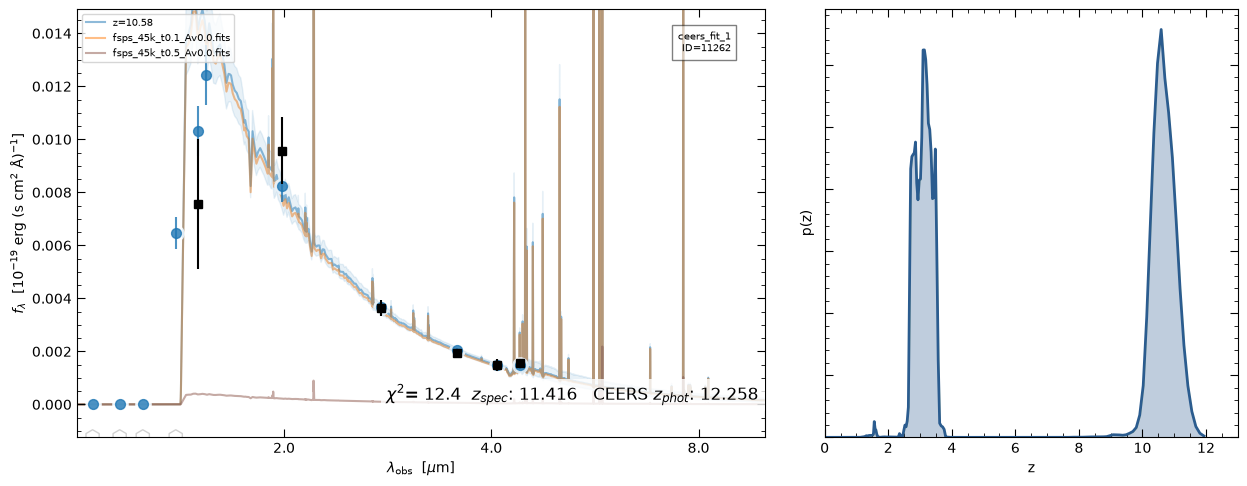

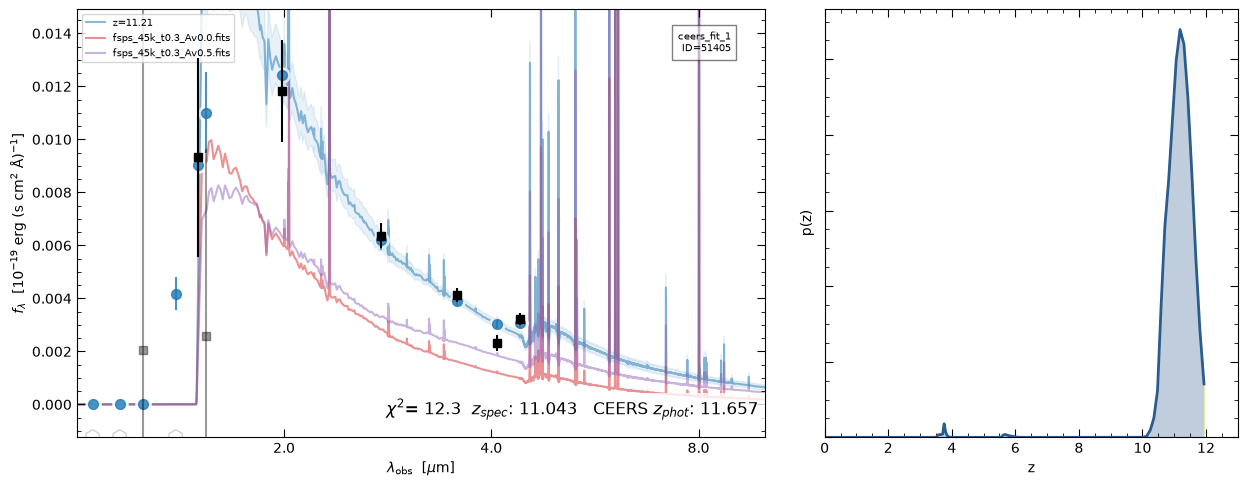

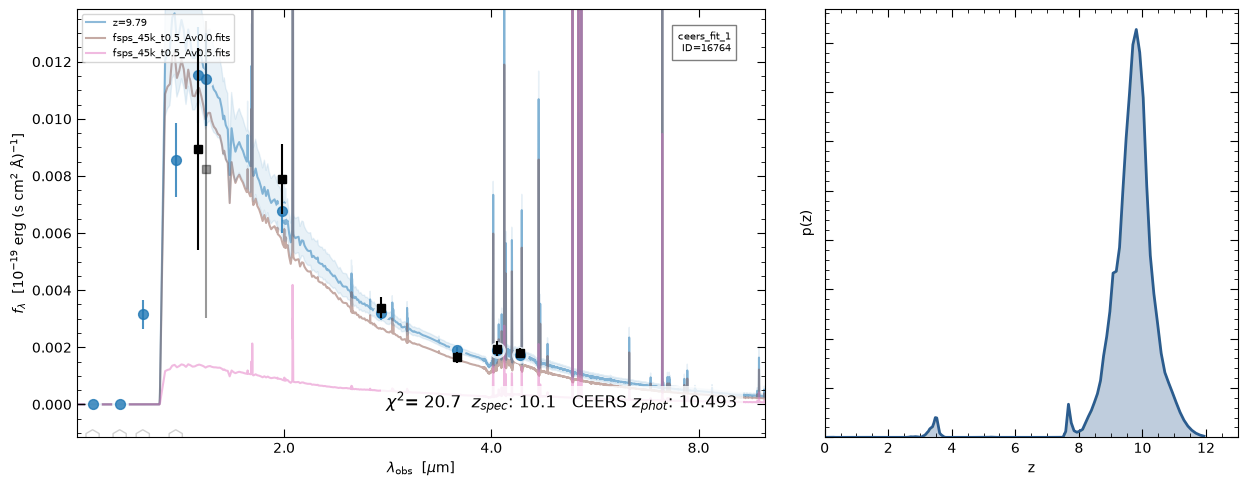

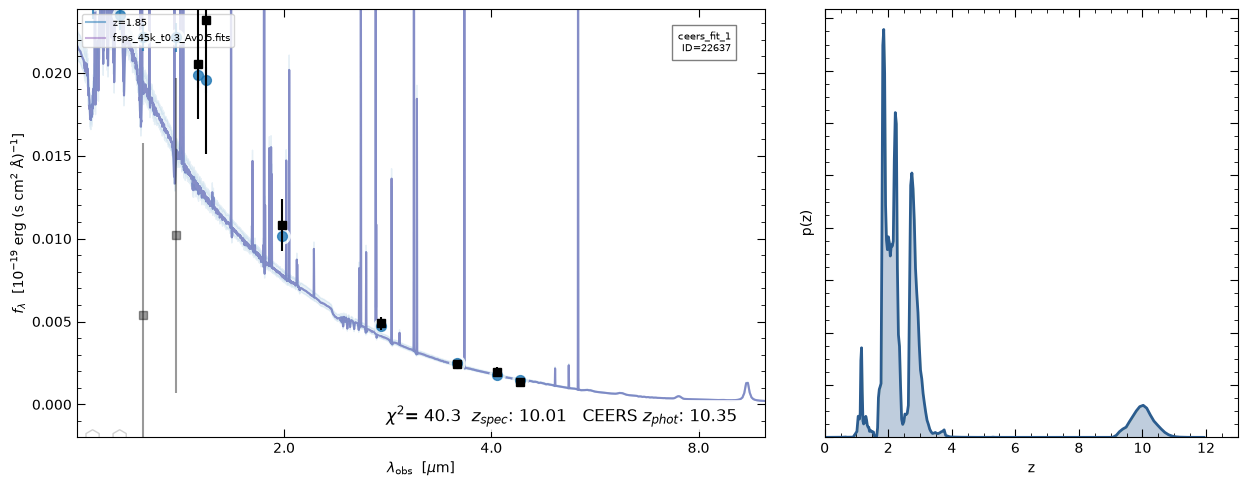

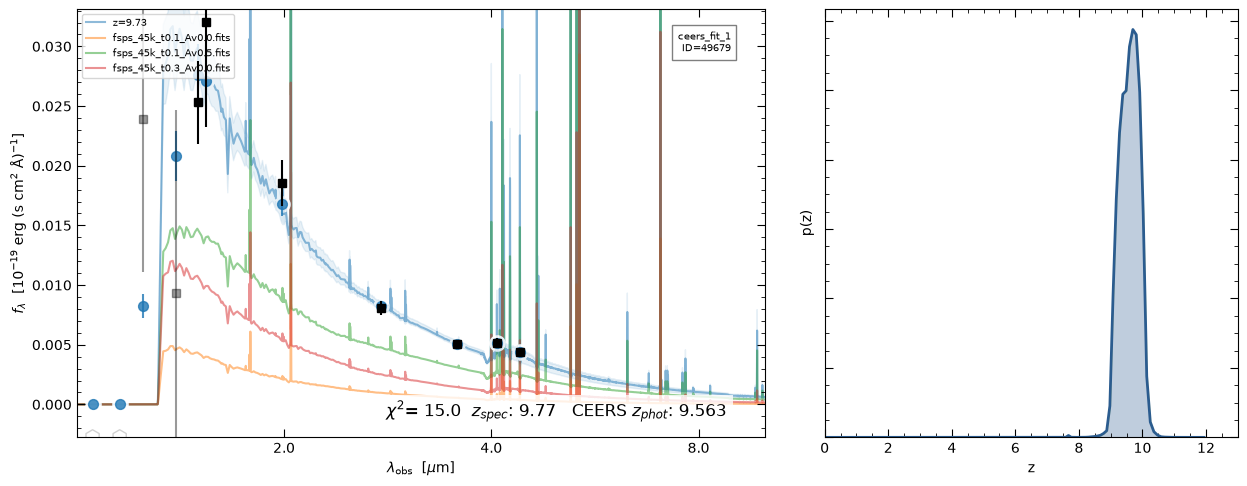

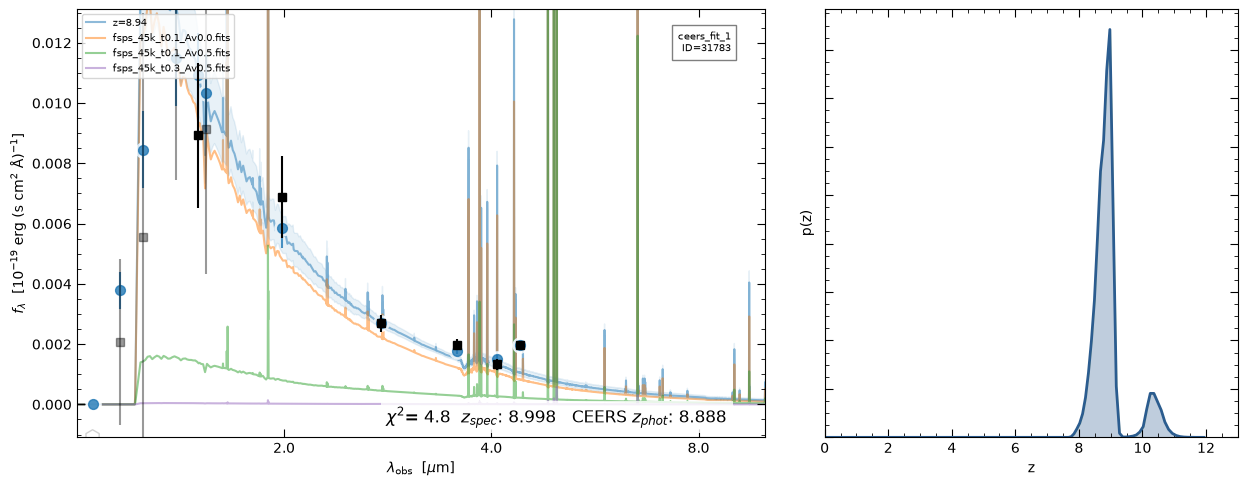

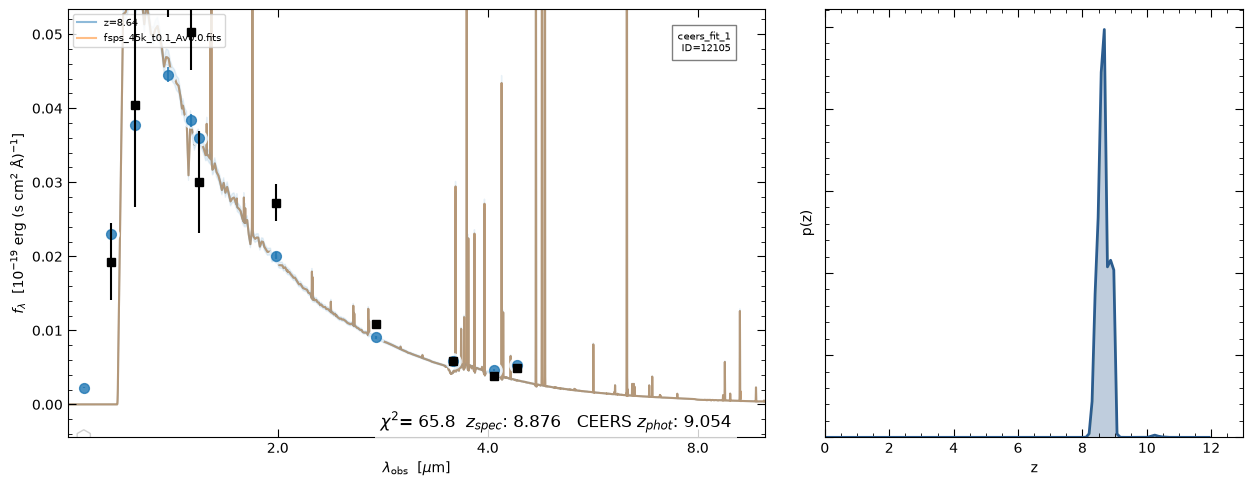

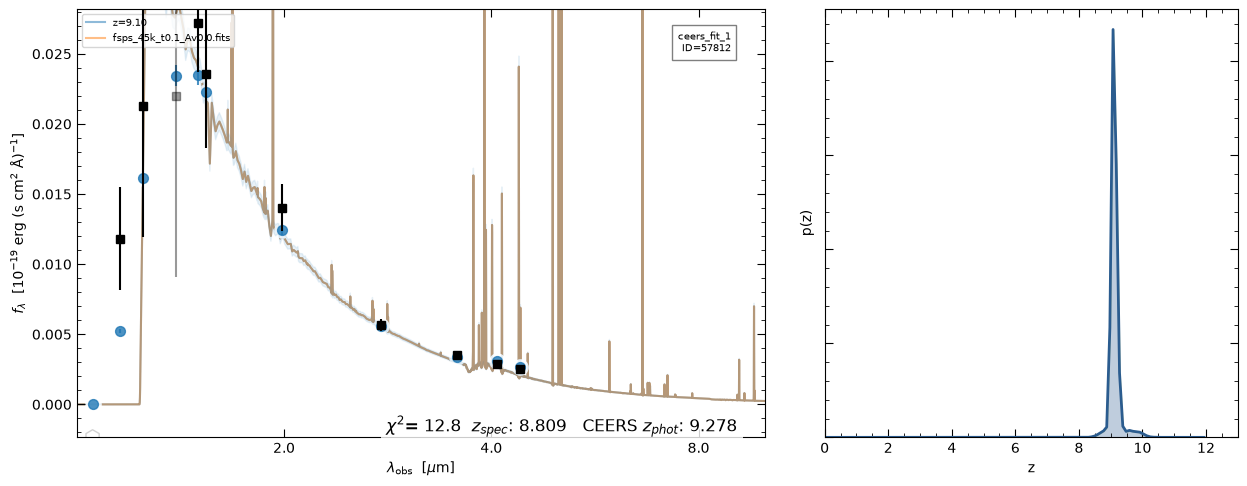

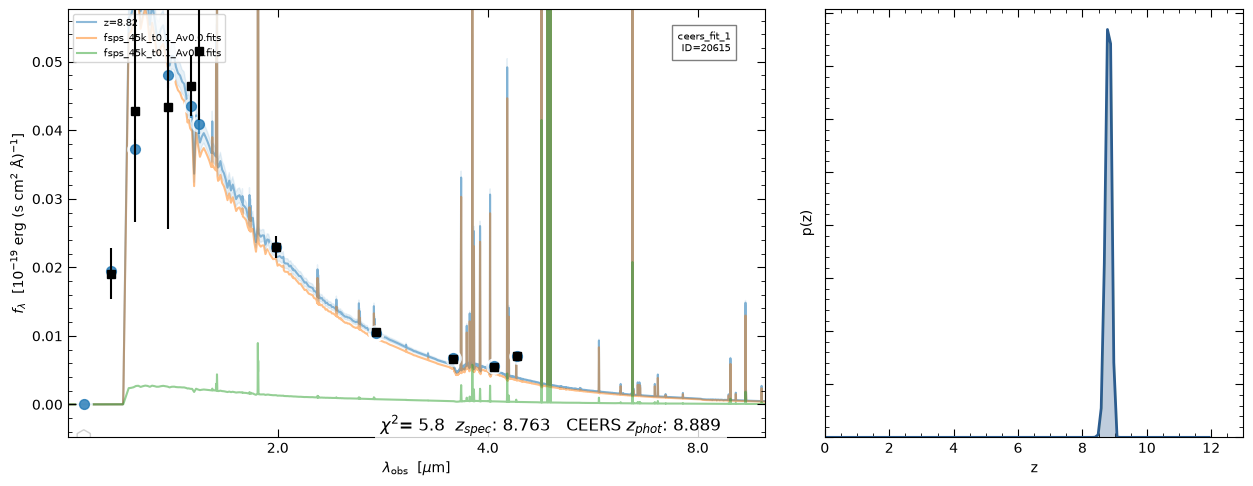

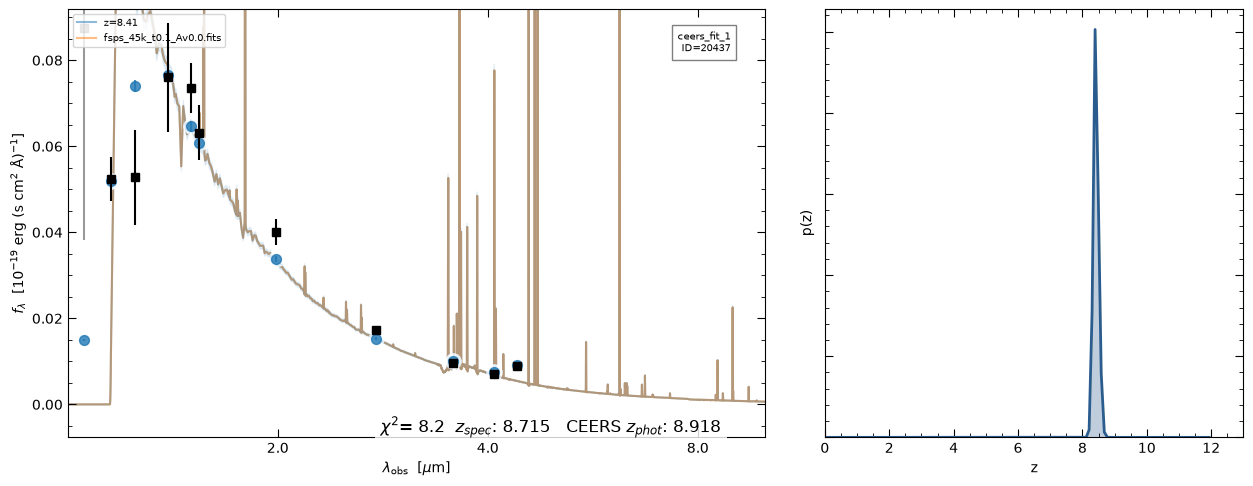

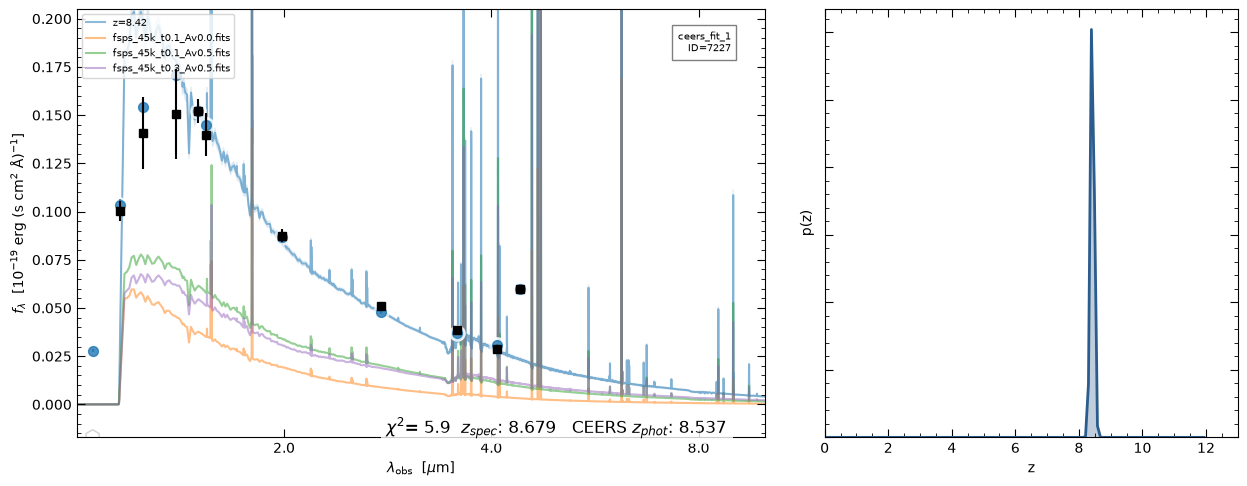

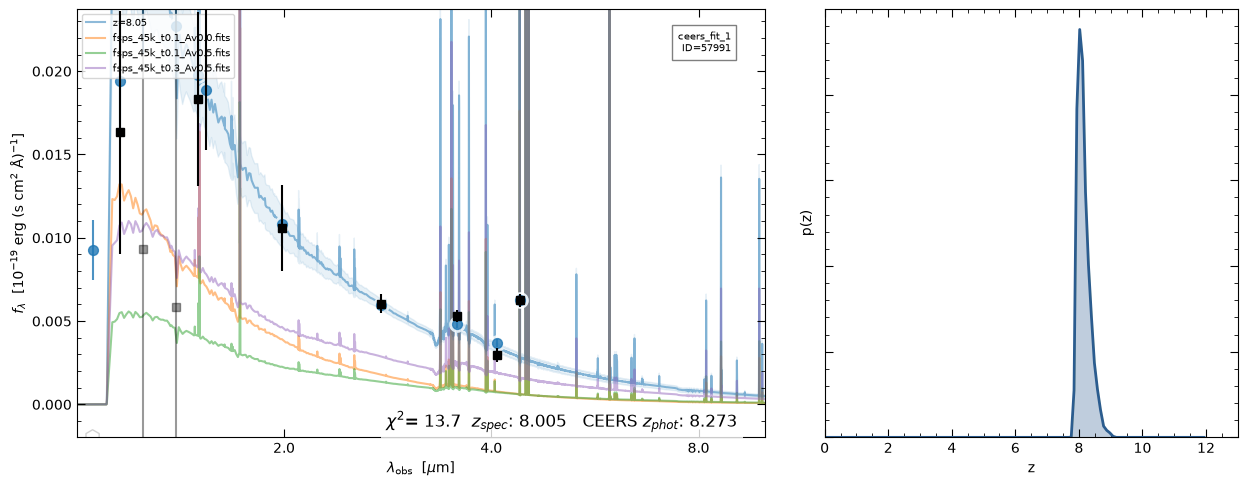

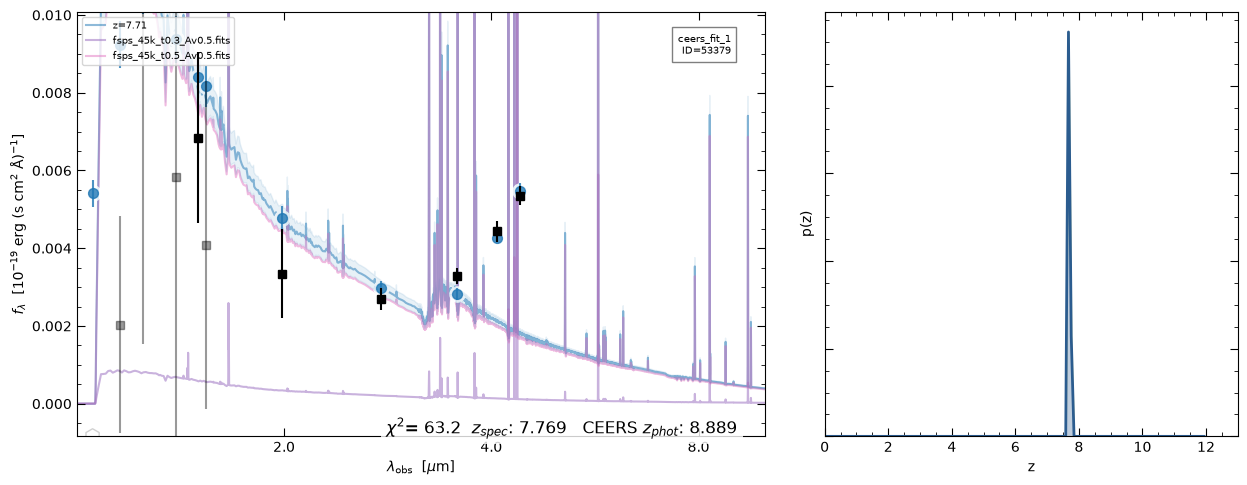

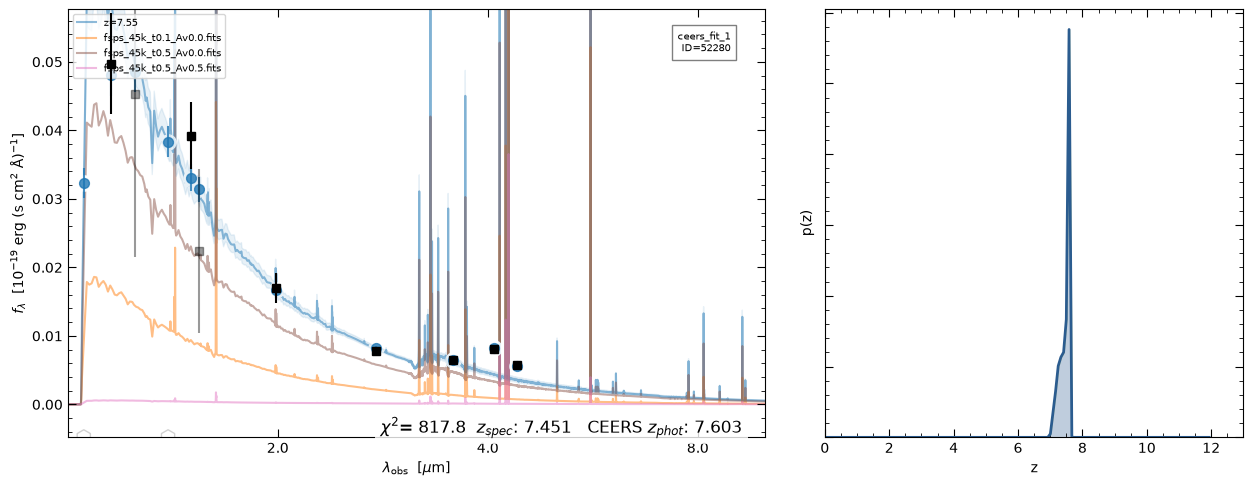

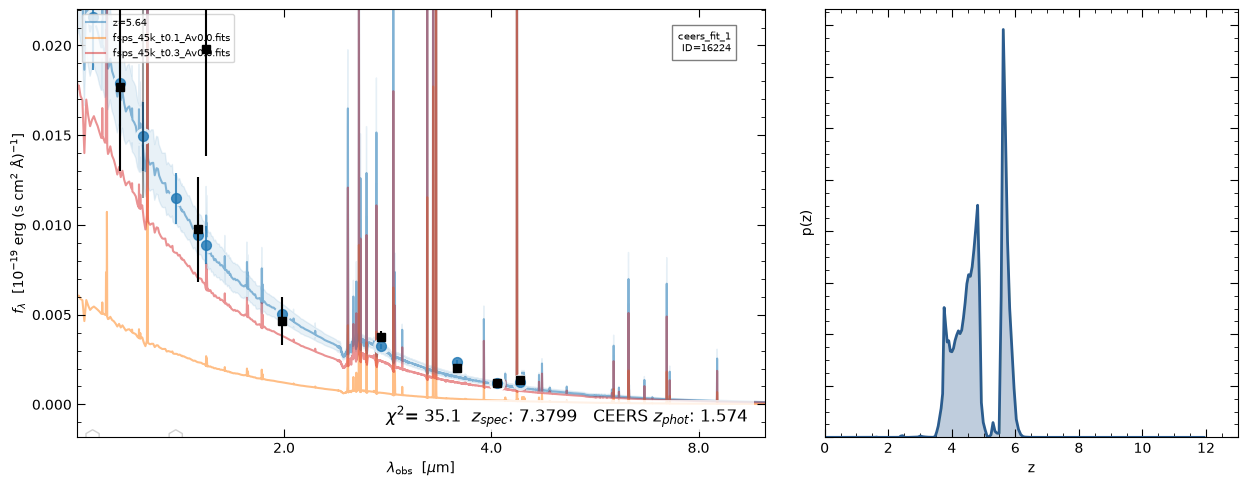

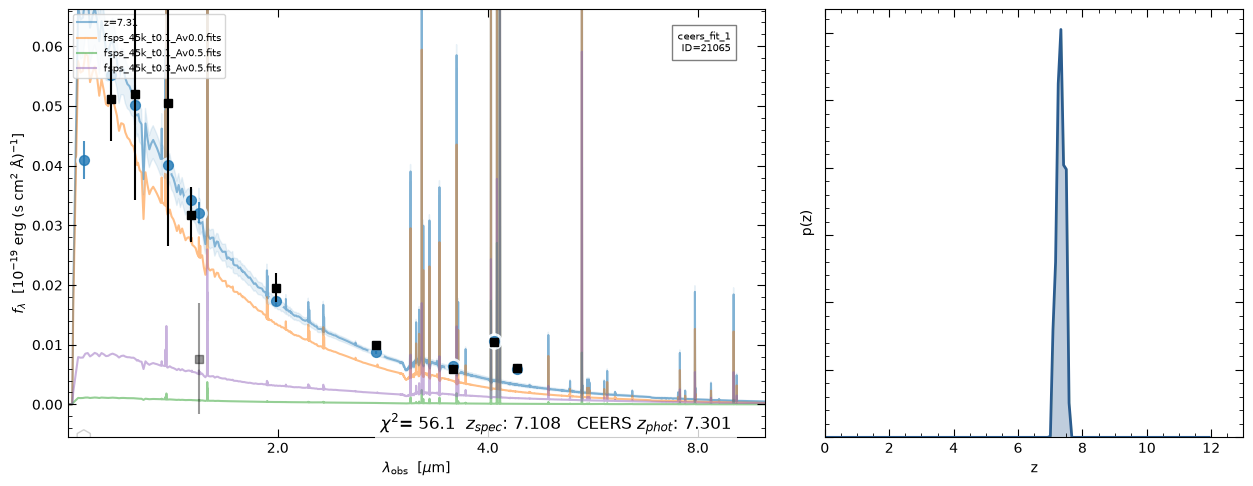

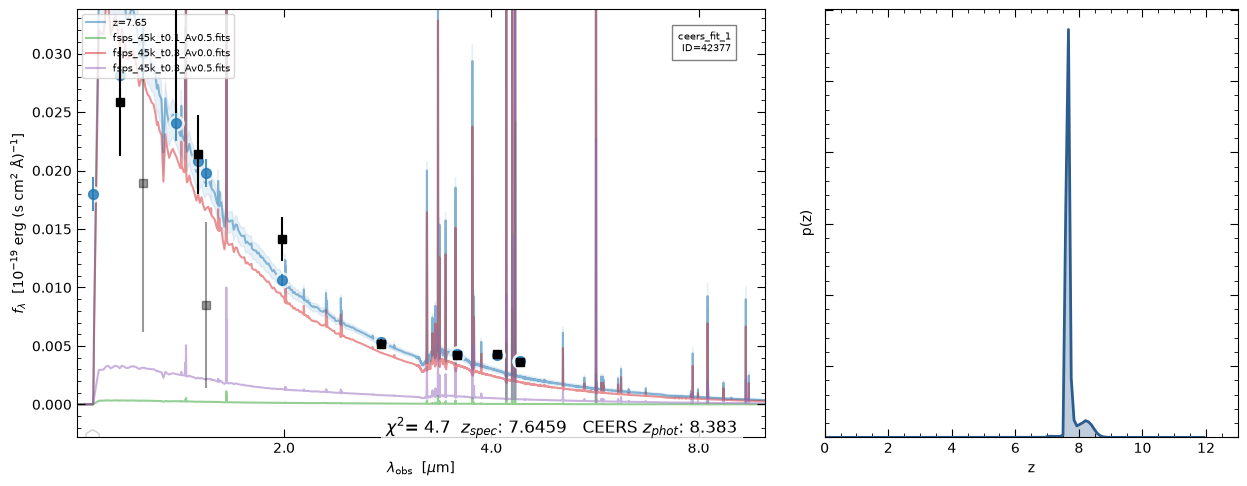

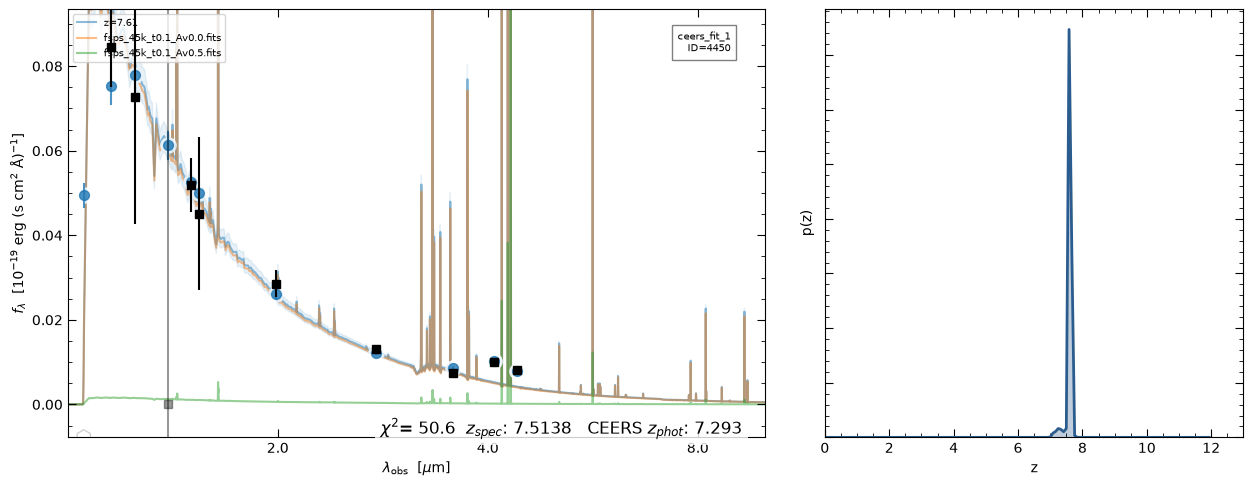

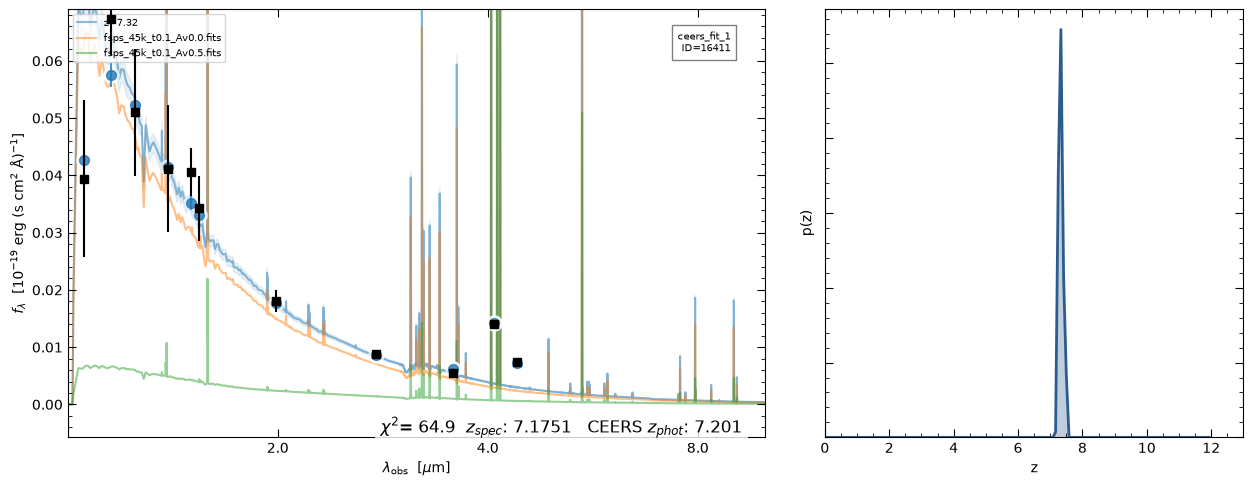

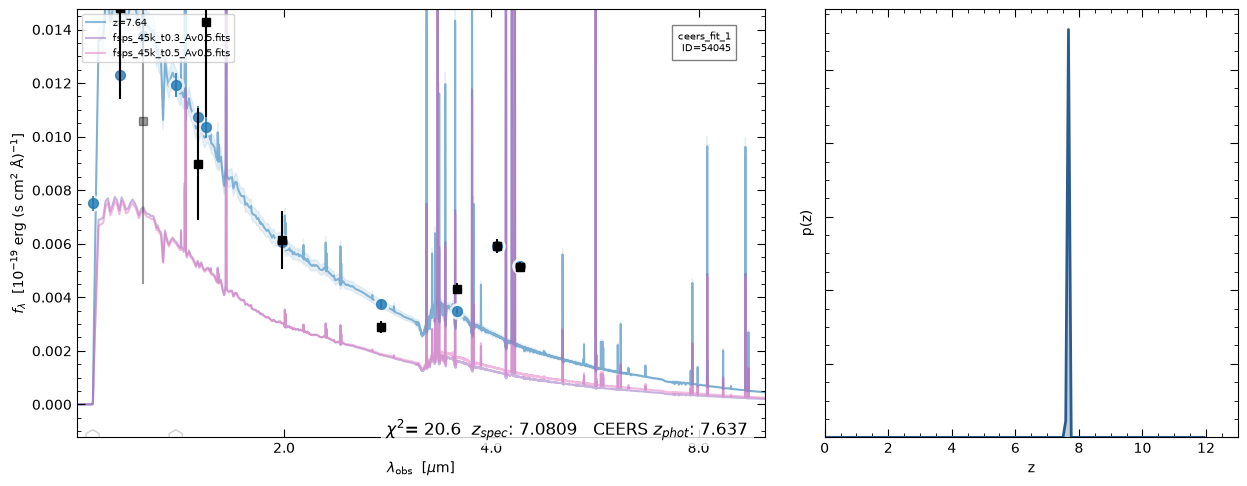

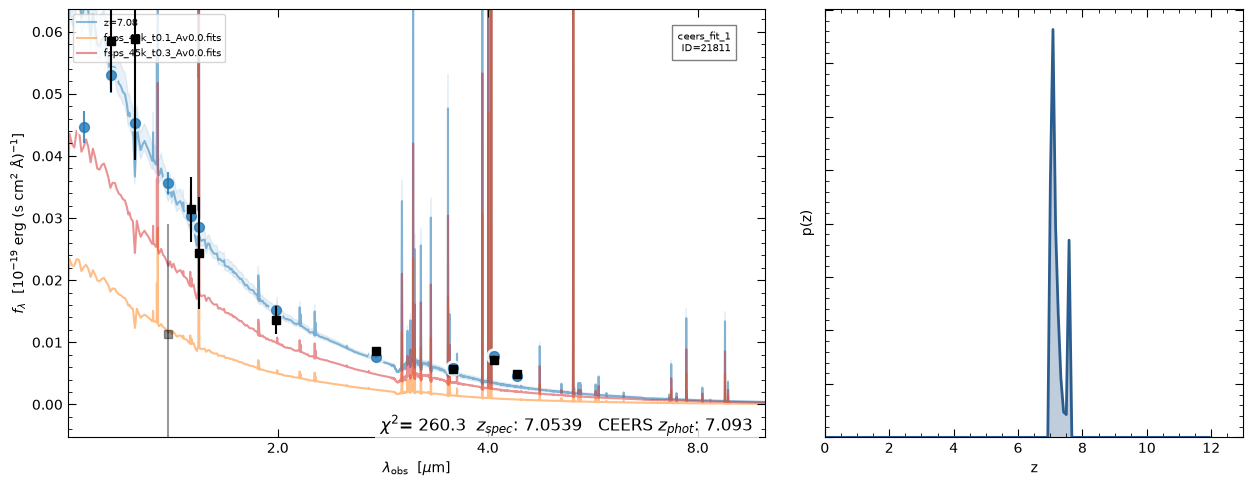

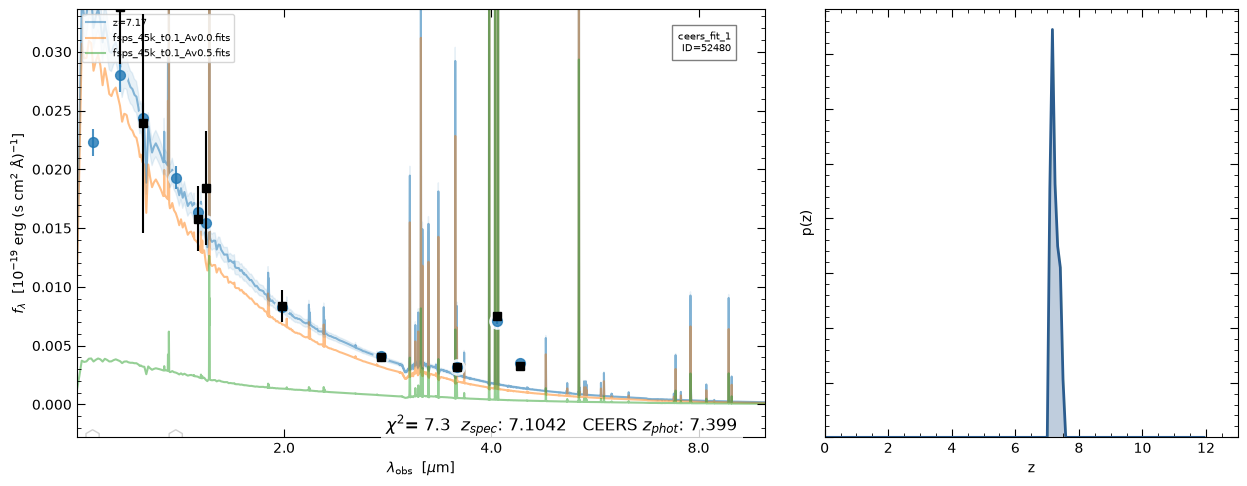

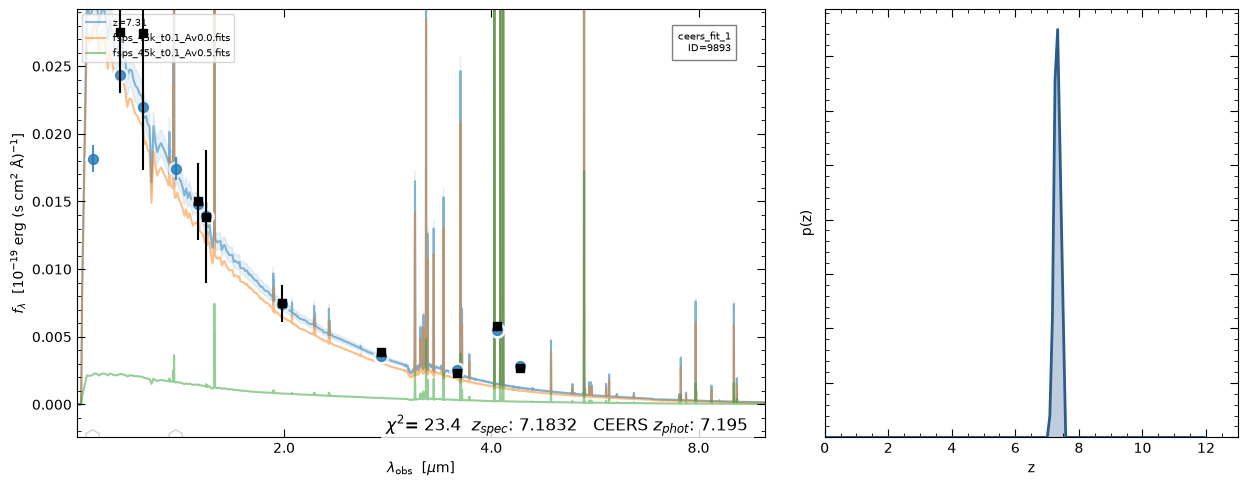

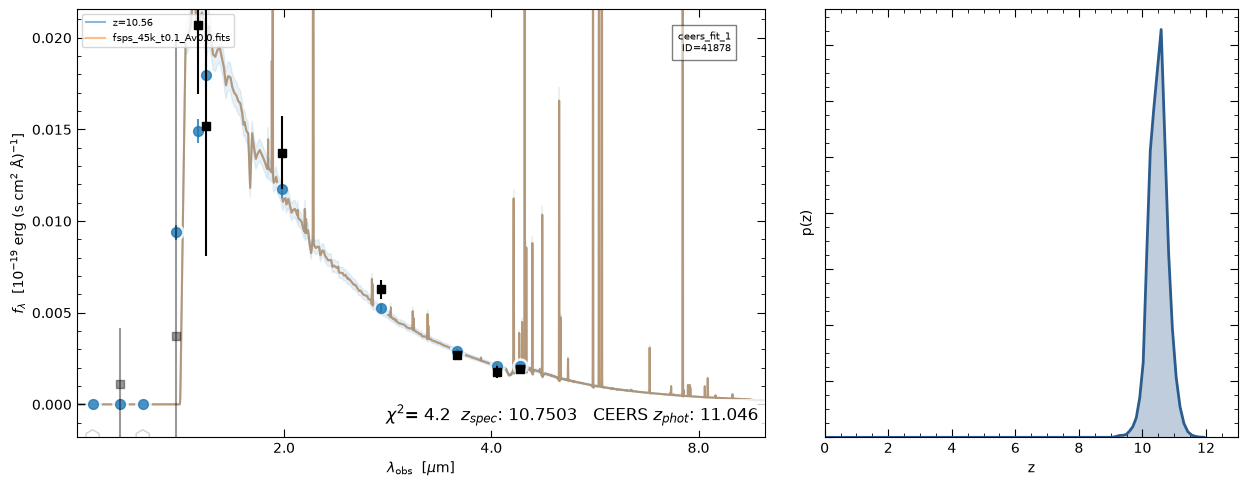

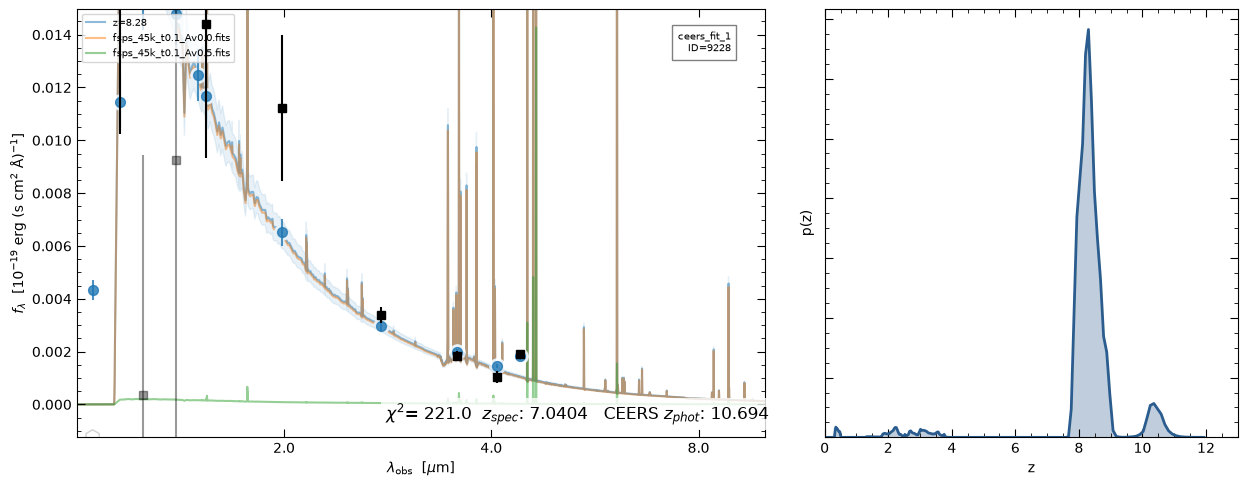

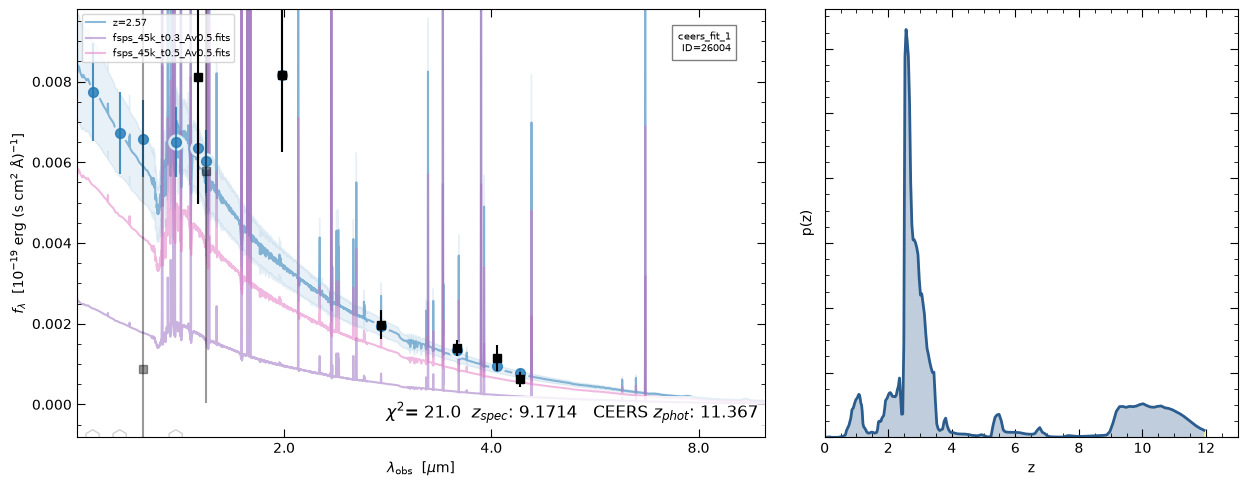

In [9]:
from matplotlib.ticker import AutoMinorLocator

ids = ez.OBJID
mask1 = zout['z_phot'] > 0
zout_masked1 = zout[mask1]
ids_masked1 = ids[mask1]

output_path = '/home/caltech-msanche3/SURF2026/scripts/ceers_fit_1.zout.fits'
output_data = Table.read(output_path)
output_data_masked = output_data[mask1]

# 52480 is a little off in coords, 16224 is too
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991,53379,52280,16224,21065,42377,4450,16411,54045,21811,52480,9893,41878,9228,26004]
zspec = [11.416,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.763,8.715,8.679,8.005,7.769,7.451,7.3799,7.108,7.6459,7.5138,7.1751,7.0809,7.0539,7.1042,7.1832,10.7503,7.0404,9.1714] 
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273,8.889,7.603,1.574,7.301,8.383,7.293,7.201,7.637,7.093,7.399,7.195,11.046,10.694,11.367]


ids_index = []
for i in range(len(ids)):
    n = np.where(zout_masked1['id']==ids[i])[0]
    ids_index.append(n.item())
print(ids_index)

#print(output_data[ids_index]['id','z_phot','z_phot_chi2','mass'])

# pass ID where ids[i] was previously passed
for i in range(len(ids)):
    fig, data = ez.show_fit(ids[i], xlim=[1, 10], show_components=True,
                            logpz=False, zr=[0,13])
    # grab ax & figs
    ax = plt.gca()
    fig = plt.gcf()
    
    # set size to be wider
    fig.set_size_inches(13, 5)
    
    # remove grid lines
    ax1 = fig.axes[0]
    ax2 = fig.axes[1]
    ax1.grid(False)
    ax2.grid(False)
    
    # change p(z)
    ax1 = fig.axes[1]
    for line in ax1.get_lines():
        line.set_color('#2b5c8f')   
        line.set_linewidth(2.0)     
    for collection in ax1.collections:
        collection.set_facecolor('#2b5c8f') 
        collection.set_alpha(0.3)          
    if ax1.get_legend():
        ax1.legend(frameon=False)

    for ax in fig.axes:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        
        ax.tick_params(
            axis='both', 
            which='both', 
            direction='in',  
            top=True,        
            right=True
        )
        
        ax.tick_params(axis='both', which='major', length=6)
        ax.tick_params(axis='both', which='minor', length=3)

    ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"CEERS $z_{phot}$: " f"{ceers_zphot[i]}", 
            fontsize=12,
            color='k',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')) 



In [12]:
print(zout['z_phot','z160','z840'])

  z_phot     z160     z840  
---------- -------- --------
 11.935818   2.2419  10.2816
      -1.0   0.0000   0.0000
 3.7469792   3.1462   3.7859
 0.2886453   0.2871   2.0126
 1.7194144   1.7117   1.8259
 2.5078814   2.3379   9.0963
0.36844507   0.3952   3.6642
 2.9866219   2.8295   3.4998
 10.046751   8.7978  10.0692
 4.7271643   4.3287   4.7815
       ...      ...      ...
 4.8419623   2.5030   5.7735
 1.9005268   0.7009   3.4103
 2.3614688   1.8934   9.2360
  5.203895   4.1677   5.1800
 1.8328412   1.6498   4.3700
 2.4854276   1.8162   4.0750
  2.888104   2.1595   4.9528
  3.503439   1.4574   3.6270
  1.027492   0.9411   2.4950
 3.8673446   2.2550   4.5259
Length = 87345 rows


ValueError: x and y must be the same size

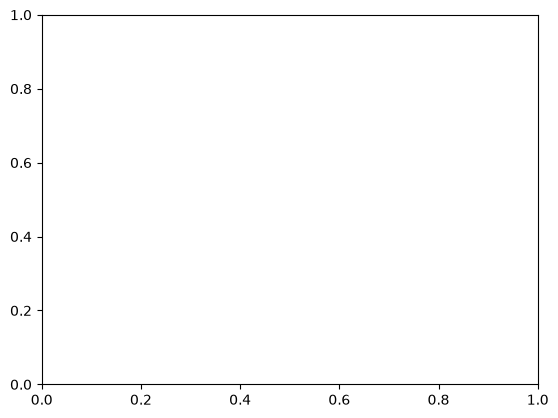

In [10]:
import matplotlib.pyplot as plt
import numpy as np
ceers_data_masked = ceers_data[mask1]


fig,ax = plt.subplots()
ax.scatter(output_data['z_phot'],ceers_data_masked['LP_Z_BEST'],alpha=.2,c='r')


    # 4. Clean up the titles and labels (use padding and font weights)
ax.set_title('CEERS photometric redshifts vs. eazy fits', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('eazy photometric redshift', fontsize=11, labelpad=10)
ax.set_ylabel('CEERS photometric redshift', fontsize=11, labelpad=10)

# 5. Make the axis tick labels look subtle
ax.tick_params(axis='both', labelsize=10,direction='in')

# 6. THE SECRET SAUCE: Subtle grid lines
# Using a very light gray, a thin width, and zorder=0 puts the grid *behind* the data lines
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)

# 7. Remove the top and right borders (spines) for an open feel
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(8,12)
ax.set_ylim(8,12)



# 8. Clean legend placement
ax.legend(frameon=False, fontsize=10, loc='upper right')

# 9. Adjust layout so nothing gets clipped
plt.tight_layout()

plt.show()


1009
1009


/tmp/ipykernel_864026/1546902768.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=10, loc='upper right')


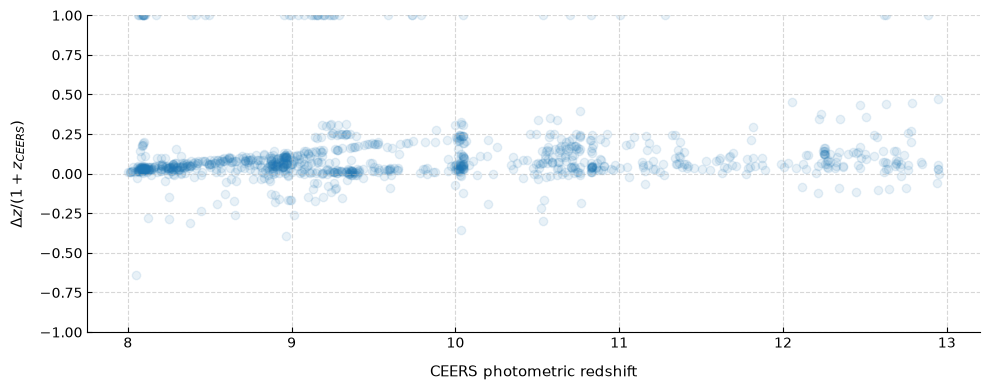

In [ ]:
dz = ceers_data_masked['LP_Z_BEST'] - output_data['z_phot']
ceers_z = ceers_data_masked['LP_Z_BEST']
err = dz/(1+ceers_z)

fig,ax = plt.subplots(figsize=(10, 4))

print(len(err))
print(len(ceers_data_masked['LP_Z_BEST']))
ax.scatter(ceers_data_masked['LP_Z_BEST'],err,alpha=.1)
ax.set_ylim(-1,1)

ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)

# 7. Remove the top and right borders (spines) for an open feel
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('CEERS photometric redshift', fontsize=11, labelpad=10)
ax.set_ylabel(r'$\Delta z/(1+z_{CEERS}$)', fontsize=11, labelpad=10)

ax.legend(frameon=False, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991,53379]
zspec = [11.416,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.763,8.715,8.679,8.005,7.769] 
for id in ids:
    print(ceers_data[np.where(ceers_data['NUMBER']==id)][0])

NUMBER  X_IMAGE   Y_IMAGE      RA       DEC    CXX_IMAGE CXY_IMAGE CYY_IMAGE THETA_IMAGE ELLIPTICITY KRON_RADIUS A_IMAGE B_IMAGE ISO_AREA STAR_FLAG BAD_REGION_FLAG APCORR_TOTAL F115W_FLUX F115W_FLUXERR_SE F115W_FLUXERR_EMP F115W_MAG F115W_MAGERR_SE F115W_MAGERR_EMP        F115W_FLUX_APER           F115W_FLUXERR_APER_SE               F115W_FLUXERR_APER_EMP            F115W_CLASS_STAR F115W_FLUX_RADIUS      F150W_FLUX        F150W_FLUXERR_SE    F150W_FLUXERR_EMP   F150W_MAG F150W_MAGERR_SE F150W_MAGERR_EMP       F150W_FLUX_APER           F150W_FLUXERR_APER_SE                F150W_FLUXERR_APER_EMP            F150W_CLASS_STAR F150W_FLUX_RADIUS      F200W_FLUX        F200W_FLUXERR_SE     F200W_FLUXERR_EMP   F200W_MAG F200W_MAGERR_SE F200W_MAGERR_EMP      F200W_FLUX_APER          F200W_FLUXERR_APER_SE                 F200W_FLUXERR_APER_EMP             F200W_CLASS_STAR F200W_FLUX_RADIUS      F277W_FLUX         F277W_FLUXERR_SE     F277W_FLUXERR_EMP   F277W_MAG F277W_MAGERR_SE F277W_MAGERR_EMP

13 13 13 13
[np.float32(10.574594), np.float32(11.204891), np.float32(9.793288), np.float32(10.023409), np.float32(9.718763), np.float32(8.934751), np.float32(8.912936), np.float32(9.083407), np.float32(8.813892), np.float32(8.411272), np.float32(8.421372), np.float32(8.037063), np.float32(7.719612)]


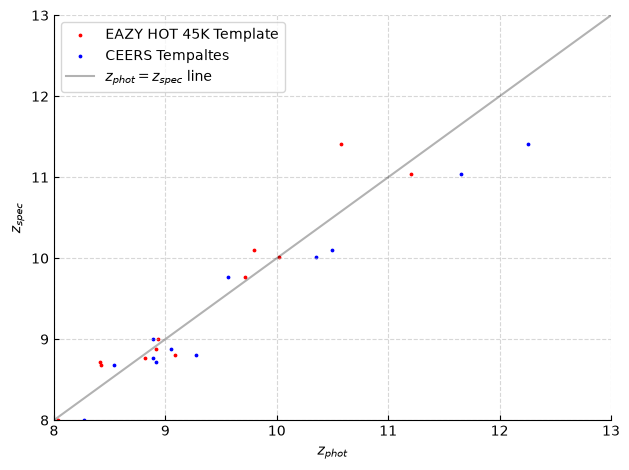

In [ ]:
#for i in range(len(ceers_data)):
    #print(ceers_data[i]['NUMBER','RA','DEC','LP_Z_BEST'])
# list of id numbers
#find their index on the masked output table
ids = [11262,51405,16764,22637,49679,31783,12105,57812,20615,20437,7227,57991,53379]
zspec = [11.416,11.043,10.10,10.01,9.77,8.998,8.876,8.809,8.763,8.715,8.679,8.005,7.769] 
ids_index = [49, 226, 78, 115, 222, 143, 56, 268, 102, 100, 34, 271, 247]
ceers_zphot = [12.258,11.657,10.493,10.350,9.563,8.888,9.054,9.278,8.889,8.918,8.537,8.273,8.889]
print(len(ids),len(zspec),len(ceers_zphot),len(ids_index))

eazy_zphot = []
for id in ids_index:
    eazy_zphot.append(output_data[id]['z_phot'])

print(eazy_zphot)

fig,ax = plt.subplots()
x = np.linspace(8,13,10)
y = np.linspace(8,13,10)
ax.scatter(eazy_zphot,zspec,c='r',s=3)
ax.scatter(ceers_zphot,zspec,c='b',s=3)
ax.plot(x,y,alpha=0.3,c='k')
ax.set_ylim(8,13)
ax.set_xlim(8,13)
ax.set_xlabel(r'$z_{phot}$')
ax.set_ylabel(r'$z_{spec}$')


ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(["EAZY HOT 45K Template",'CEERS Tempaltes',r'$z_{phot} = z_{spec}$ line'])
plt.tight_layout()

[np.float32(0.06776795), np.float32(-0.013442745), np.float32(0.027631724), np.float32(-0.001217862), np.float32(0.0047573913), np.float32(0.0063262237), np.float32(-0.0037399558), np.float32(-0.027975062), np.float32(-0.005212827), np.float32(0.03126383), np.float32(0.02661716), np.float32(-0.0035605254), np.float32(0.0056321053)]
[-0.06781572164948443, -0.050983974092834075, -0.03540540540540547, -0.030881017257039043, 0.01922005571030631, 0.011002200440087961, -0.018023491292021146, -0.047813232745437986, -0.012905869097613381, -0.02089552238805964, 0.014670937080276832, -0.02976124375347017, -0.1277226593682289]
Average CEERS Templates z_phot absolute error: 3.747e-02
Average EAZY HOT 45K Templates z_phot absolute error: 1.732e-02


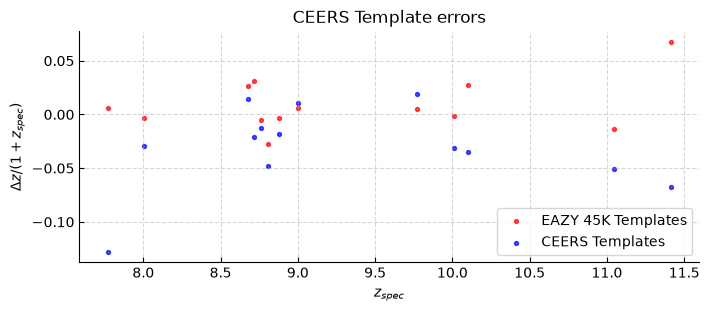

In [ ]:
ceers_err = []
eazy_err = []

for i in range(13):
    ceers_err.append((zspec[i]-ceers_zphot[i])/(1+zspec[i]))
    eazy_err.append((zspec[i]-eazy_zphot[i])/(1+zspec[i]))
print(eazy_err)
print(ceers_err)
'''
ez_ct = 0
ceers_ct = 0
for i in range(13):
    if eazy_err[i] > 0.15:
        ez_ct +=1
    if ceers_err > 0.15:
        ceers_ct += 1
print(ez_ct)
print(ceers_ct)
'''
print(f"Average CEERS Templates z_phot absolute error: {np.mean(np.abs(ceers_err)):.3e}")
print(f"Average EAZY HOT 45K Templates z_phot absolute error: {np.mean(np.abs(eazy_err)):.3e}")

fig,ax = plt.subplots(figsize=(8,3))
ax.scatter(zspec,eazy_err,alpha=0.7,c='r',s=8)
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("EAZY HOT 45K Template errors")
ax.scatter(zspec,ceers_err,alpha=0.7,c='b',s=8)
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.set_xlabel(r"$z_{spec}$")
ax.set_ylabel(r"$\Delta z/(1+z_{spec})$")
ax.set_title("CEERS Template errors")
ax.legend(["EAZY 45K Templates","CEERS Templates"])


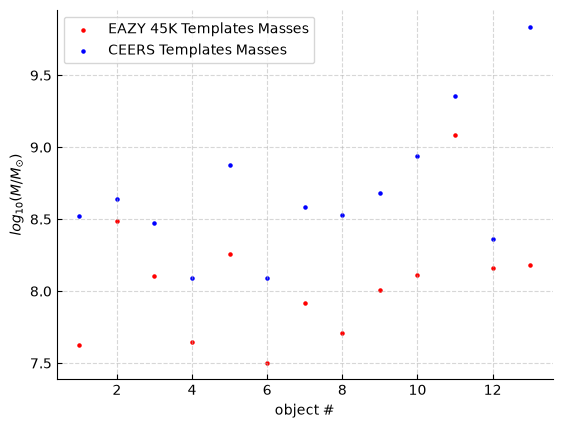

In [ ]:
eazy_mass = []
ceers_mass  = []
x = np.linspace(1,13,13)
for id in ids_index:
    #print(f'eazy mass:',np.log10(output_data[id]['mass']))
    eazy_mass.append(np.log10(output_data[id]['mass']))
    #print(f'ceers mass:',ceers_data_masked[id]['LP_MASS_BEST'],"\n")
    ceers_mass.append(ceers_data_masked[id]['LP_MASS_BEST'])

fig,ax = plt.subplots()
ax.scatter(x,eazy_mass,c='r',s=5)
ax.scatter(x,ceers_mass,c='b',s=5)
ax.set_xlabel('object #')
ax.set_ylabel(r'$log_{10}(M/M_{\odot})$')
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(["EAZY 45K Templates Masses","CEERS Templates Masses"])
